
# Which Factors Are Associated With Student Performance?

**A first data-science portfolio project — exploratory data analysis (EDA)**

**Dataset:** [Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)
(1,000 students; gender, race/ethnicity, parental level of education, lunch type,
test preparation course, and scores in math, reading, and writing)

**Objective:** Explore which student- and family-level factors are *associated*
with exam performance, using missing-value checks, summary statistics, grade
distributions, and correlation analysis — the standard first steps of any
data-science workflow, without needing machine learning.

**Workflow**
1. Load & inspect the data
2. Missing-value checks
3. Feature engineering (average score, letter grade)
4. Summary statistics
5. Grade distributions
6. Correlation analysis
7. Factors associated with performance (group comparisons)
8. Key findings
9. Limitations


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Professional, colorblind-friendly plotting defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (9, 5.5),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})
PALETTE = sns.color_palette("colorblind")
sns.set_palette(PALETTE)

pd.set_option('display.max_columns', None)


## 1. Load & Inspect the Data

In [2]:

df = pd.read_csv('StudentsPerformance.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
df.head()


Shape: 1000 rows x 8 columns



,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## 2. Missing-Value Checks

Before doing anything else, we check for nulls, duplicate rows, and
implausible values (scores outside the valid 0–100 range).


In [4]:

missing = df.isnull().sum().to_frame('missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(2)
print("Missing values per column:")
display(missing)

print(f"\nDuplicate rows: {df.duplicated().sum()}")

score_cols = ['math score', 'reading score', 'writing score']
out_of_range = ((df[score_cols] < 0) | (df[score_cols] > 100)).sum()
print("\nOut-of-range scores (should be 0):")
print(out_of_range)


Missing values per column:


,missing_count,missing_pct
gender,0,0.0
race/ethnicity,0,0.0
parental level of education,0,0.0
lunch,0,0.0
test preparation course,0,0.0
math score,0,0.0
reading score,0,0.0
writing score,0,0.0



Duplicate rows: 0

Out-of-range scores (should be 0):
math score       0
reading score    0
writing score    0
dtype: int64


**Result:** this dataset has **zero missing values, zero duplicate rows,
and no out-of-range scores** — it is already clean. Running the check is still
essential practice: on most real-world datasets this step surfaces problems
that must be handled (dropped, imputed, or flagged) before any analysis is
trustworthy.

## 3. Feature Engineering

We derive two convenience columns used throughout the rest of the analysis:
- **`average_score`** — the mean of the three subject scores
- **`grade`** — a letter grade banded off `average_score` (A ≥ 90, B ≥ 80, C ≥ 70, D ≥ 60, F < 60)


In [5]:

df['average_score'] = df[score_cols].mean(axis=1).round(2)

def to_grade(score):
    if score >= 90: return 'A'
    if score >= 80: return 'B'
    if score >= 70: return 'C'
    if score >= 60: return 'D'
    return 'F'

df['grade'] = df['average_score'].apply(to_grade)
df[['math score', 'reading score', 'writing score', 'average_score', 'grade']].head()


,math score,reading score,writing score,average_score,grade
0,72,72,74,72.67,C
1,69,90,88,82.33,B
2,90,95,93,92.67,A
3,47,57,44,49.33,F
4,76,78,75,76.33,C


## 4. Summary Statistics

In [6]:

print("Numeric columns:")
display(df[score_cols + ['average_score']].describe().round(2))


Numeric columns:


,math score,reading score,writing score,average_score
count,1000.00,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05,67.77
std,15.16,14.60,15.20,14.26
min,0.00,17.00,10.00,9.00
25%,57.00,59.00,57.75,58.33
50%,66.00,70.00,69.00,68.33
75%,77.00,79.00,79.00,77.67
max,100.00,100.00,100.00,100.00


In [7]:

cat_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
for c in cat_cols:
    print(f"\n{c} (n={df[c].nunique()} categories):")
    print(df[c].value_counts())



gender (n=2 categories):
gender
female    518
male      482
Name: count, dtype: int64

race/ethnicity (n=5 categories):
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

parental level of education (n=6 categories):
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

lunch (n=2 categories):
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

test preparation course (n=2 categories):
test preparation course
none         642
completed    358
Name: count, dtype: int64


## 5. Grade Distributions

### Chart 1 — Distribution of letter grades

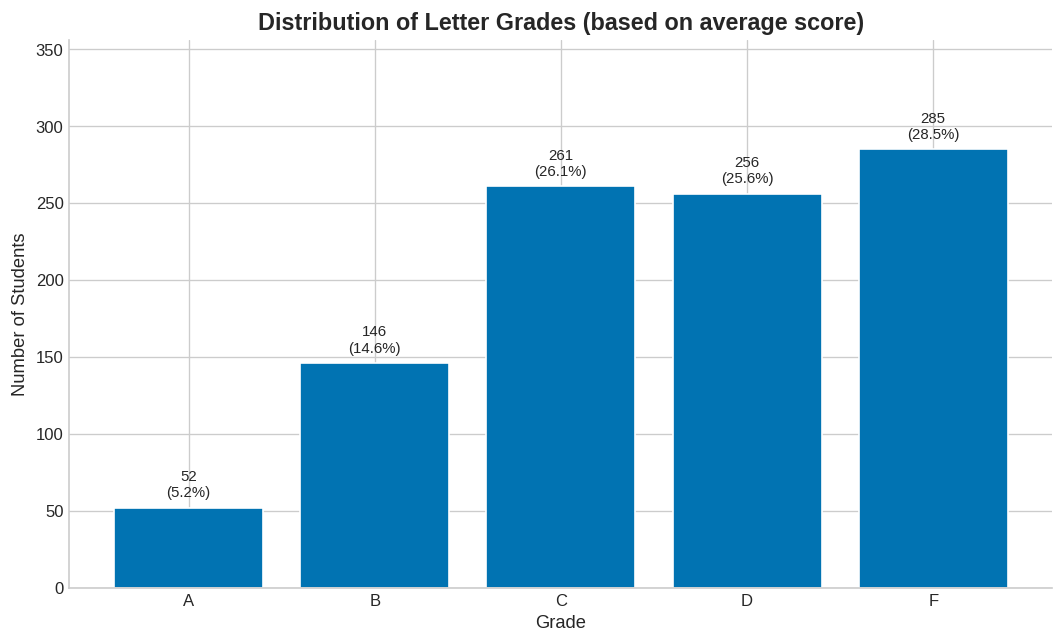

In [8]:

grade_order = ['A', 'B', 'C', 'D', 'F']
grade_counts = df['grade'].value_counts().reindex(grade_order)

fig, ax = plt.subplots()
bars = ax.bar(grade_counts.index, grade_counts.values, color=PALETTE[0], edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 5, f'{h:,}\n({h/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

ax.set_title('Distribution of Letter Grades (based on average score)')
ax.set_xlabel('Grade')
ax.set_ylabel('Number of Students')
ax.set_ylim(0, grade_counts.max() * 1.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart1_grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### Score distributions (math, reading, writing)

Alongside letter grades, it helps to see the raw score distributions
directly — this is what the letter-grade bands were carved out of.

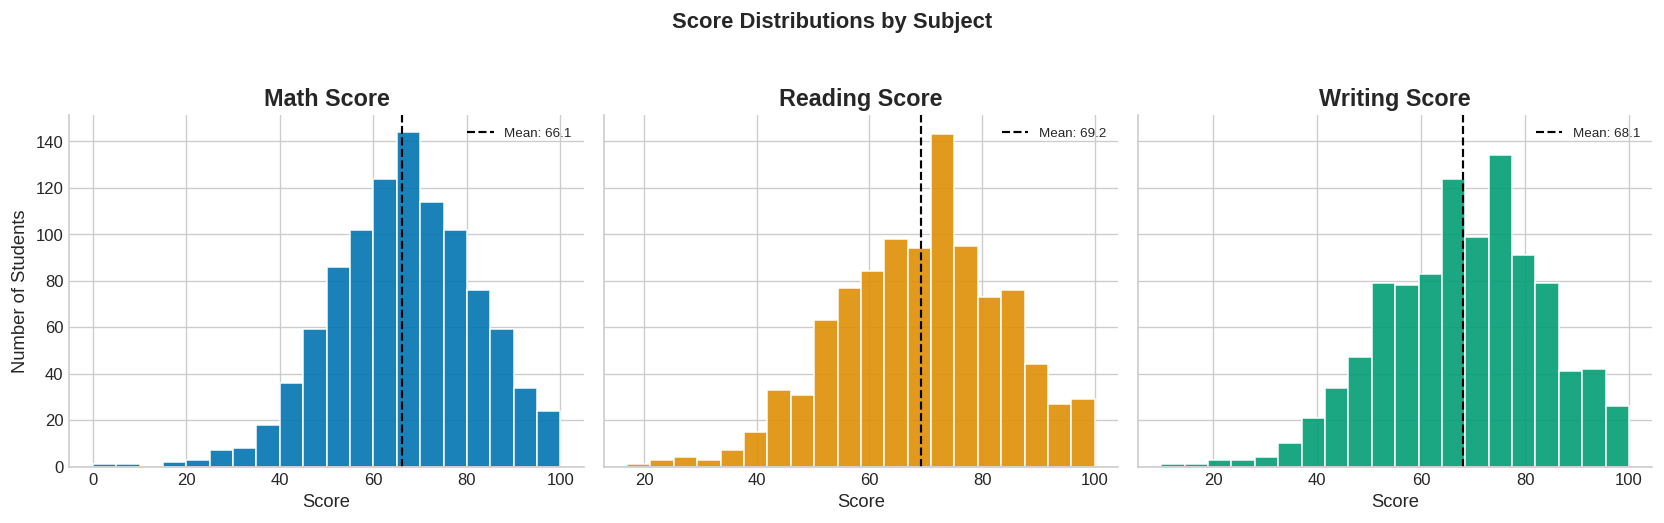

In [9]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, col, color in zip(axes, score_cols, PALETTE):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.9)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.3,
               label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(col.title())
    ax.set_xlabel('Score')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('Number of Students')
fig.suptitle('Score Distributions by Subject', fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Correlation Analysis

### Chart 2 — Correlation heatmap

How strongly are the three subject scores related to one another?

,math score,reading score,writing score,average_score
math score,1.00,0.82,0.80,0.92
reading score,0.82,1.00,0.95,0.97
writing score,0.80,0.95,1.00,0.97
average_score,0.92,0.97,0.97,1.00


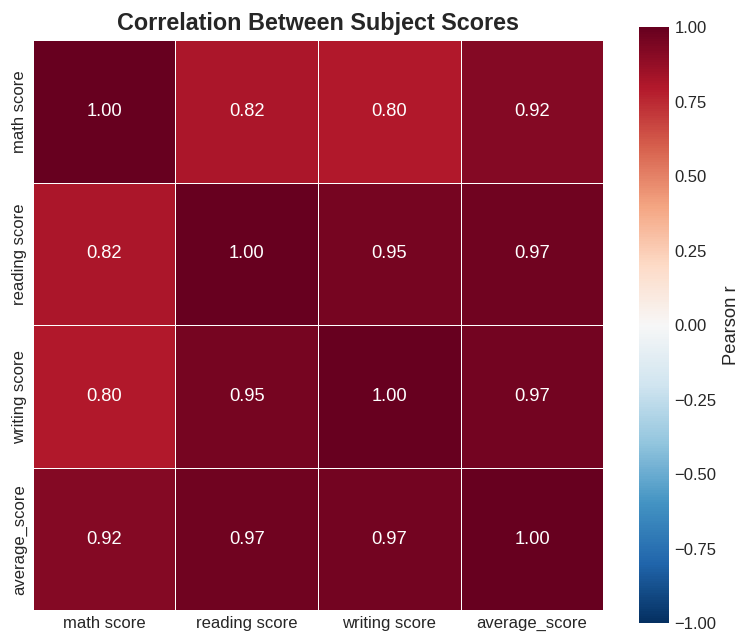

In [10]:

corr = df[score_cols + ['average_score']].corr()
display(corr.round(2))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlation Between Subject Scores')
plt.tight_layout()
plt.savefig('chart2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### Chart 3 — Math vs. reading score, by test preparation

A scatter plot lets us see the *shape* of the relationship (not just the
correlation coefficient), and whether test preparation shifts the whole
cloud of points up.

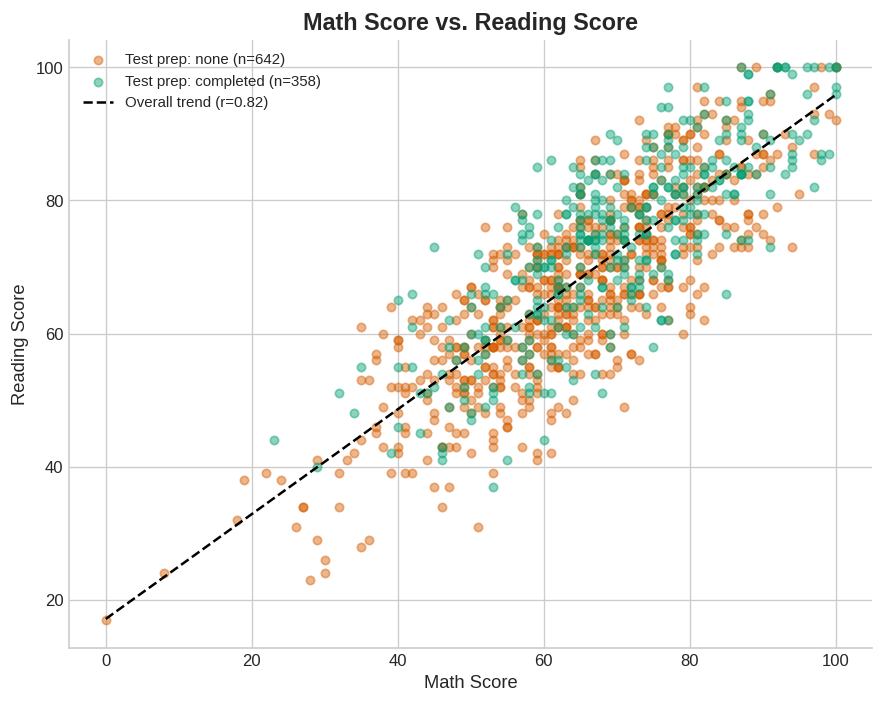

In [11]:

fig, ax = plt.subplots(figsize=(7.5, 6))
for prep, color in zip(['none', 'completed'], [PALETTE[3], PALETTE[2]]):
    sub = df[df['test preparation course'] == prep]
    ax.scatter(sub['math score'], sub['reading score'], alpha=0.45, s=25,
               color=color, label=f'Test prep: {prep} (n={len(sub)})')

# overall trend line
z = np.polyfit(df['math score'], df['reading score'], 1)
xs = np.linspace(df['math score'].min(), df['math score'].max(), 100)
ax.plot(xs, np.polyval(z, xs), color='black', linewidth=1.5, linestyle='--',
        label=f'Overall trend (r={corr.loc["math score","reading score"]:.2f})')

ax.set_title('Math Score vs. Reading Score')
ax.set_xlabel('Math Score')
ax.set_ylabel('Reading Score')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_math_vs_reading_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


**Reading:** math, reading, and writing scores are all **strongly,
positively correlated** with one another (r ≈ 0.8–0.95) — students who do
well in one subject tend to do well in the others, consistent with a shared
underlying "general academic performance" factor plus subject-specific
variation. Reading and writing are the most tightly linked (r ≈ 0.95),
which makes sense since both draw on overlapping literacy skills.

## 7. Factors Associated With Performance

Next we look at whether *categorical* factors — test preparation, parental
education, lunch type (a proxy for socioeconomic status), and gender — are
associated with average score. For each factor we report group means and a
simple hypothesis test (t-test for two groups, one-way ANOVA for more than
two) so we're not just eyeballing bar height differences.

In [12]:

# Test preparation course: two groups -> independent t-test
prep_none = df.loc[df['test preparation course'] == 'none', 'average_score']
prep_done = df.loc[df['test preparation course'] == 'completed', 'average_score']
t_stat, p_val = stats.ttest_ind(prep_done, prep_none, equal_var=False)

print("Average score by test preparation course:")
print(df.groupby('test preparation course')['average_score'].agg(['mean', 'std', 'count']).round(2))
print(f"\nWelch's t-test (completed vs. none): t={t_stat:.2f}, p={p_val:.2e}")


Average score by test preparation course:
                          mean    std  count
test preparation course                     
completed                72.67  13.04    358
none                     65.04  14.19    642

Welch's t-test (completed vs. none): t=8.59, p=4.42e-17


In [13]:

# Parental level of education: >2 groups -> one-way ANOVA
edu_groups = [g['average_score'].values for _, g in df.groupby('parental level of education')]
f_stat, p_val_edu = stats.f_oneway(*edu_groups)

edu_order = df.groupby('parental level of education')['average_score'].mean().sort_values().index
print("Average score by parental level of education (sorted):")
print(df.groupby('parental level of education')['average_score'].agg(['mean', 'std', 'count']).loc[edu_order].round(2))
print(f"\nOne-way ANOVA across education levels: F={f_stat:.2f}, p={p_val_edu:.2e}")


Average score by parental level of education (sorted):
                              mean    std  count
parental level of education                     
high school                  63.10  13.51    196
some high school             65.11  14.98    179
some college                 68.48  13.71    226
associate's degree           69.57  13.67    222
bachelor's degree            71.92  13.95    118
master's degree              73.60  13.60     59

One-way ANOVA across education levels: F=10.75, p=4.38e-10


In [14]:

# Lunch type (socioeconomic proxy) and gender: two groups each -> t-tests
lunch_std = df.loc[df['lunch'] == 'standard', 'average_score']
lunch_fr = df.loc[df['lunch'] == 'free/reduced', 'average_score']
t_lunch, p_lunch = stats.ttest_ind(lunch_std, lunch_fr, equal_var=False)

male = df.loc[df['gender'] == 'male', 'average_score']
female = df.loc[df['gender'] == 'female', 'average_score']
t_gender, p_gender = stats.ttest_ind(female, male, equal_var=False)

print("Average score by lunch type:")
print(df.groupby('lunch')['average_score'].agg(['mean', 'std', 'count']).round(2))
print(f"Welch's t-test (standard vs. free/reduced): t={t_lunch:.2f}, p={p_lunch:.2e}\n")

print("Average score by gender:")
print(df.groupby('gender')['average_score'].agg(['mean', 'std', 'count']).round(2))
print(f"Welch's t-test (female vs. male): t={t_gender:.2f}, p={p_gender:.2e}")


Average score by lunch type:
               mean    std  count
lunch                            
free/reduced  62.20  14.46    355
standard      70.84  13.19    645
Welch's t-test (standard vs. free/reduced): t=9.32, p=1.58e-19

Average score by gender:
         mean    std  count
gender                     
female  69.57  14.54    518
male    65.84  13.70    482
Welch's t-test (female vs. male): t=4.18, p=3.18e-05


### Chart 4 — Average score by test preparation course

/tmp/ipykernel_185/1002530742.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test preparation course', y='average_score', order=order,


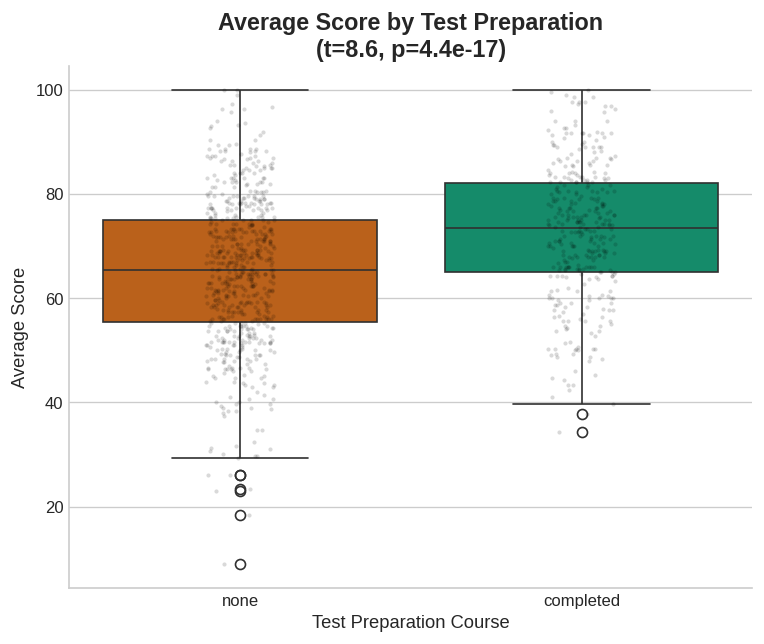

In [15]:

fig, ax = plt.subplots(figsize=(6.5, 5.5))
order = ['none', 'completed']
sns.boxplot(data=df, x='test preparation course', y='average_score', order=order,
            palette=[PALETTE[3], PALETTE[2]], ax=ax)
sns.stripplot(data=df, x='test preparation course', y='average_score', order=order,
              color='black', alpha=0.15, size=2.5, ax=ax)

ax.set_title(f'Average Score by Test Preparation\n(t={t_stat:.1f}, p={p_val:.1e})')
ax.set_xlabel('Test Preparation Course')
ax.set_ylabel('Average Score')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart4_score_by_test_prep.png', dpi=150, bbox_inches='tight')
plt.show()


### Chart 5 — Average score by parental level of education

/tmp/ipykernel_185/229014456.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='parental level of education', y='average_score',


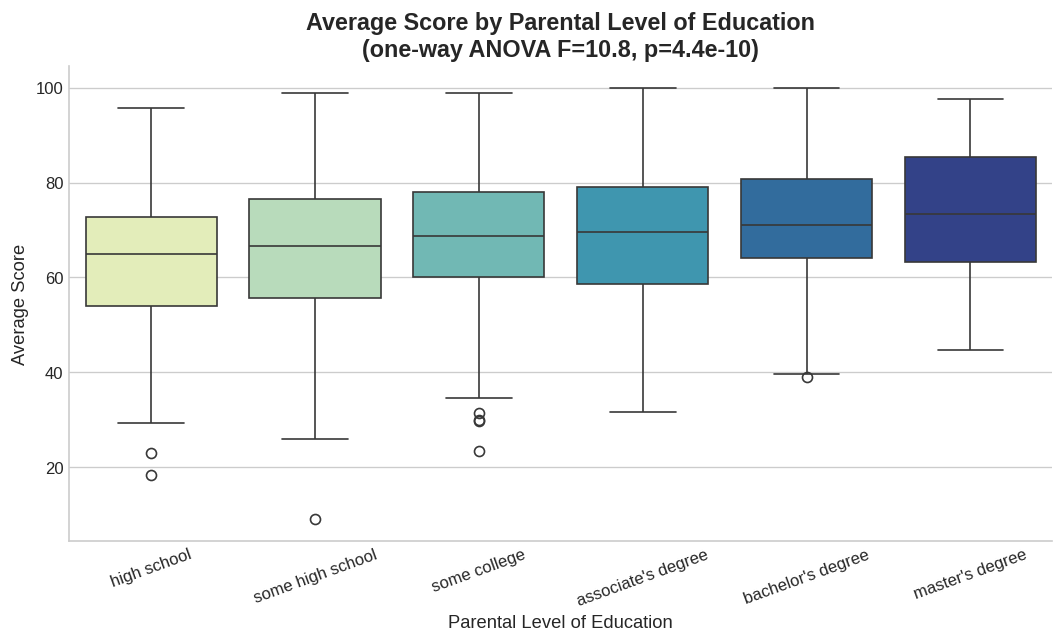

In [16]:

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df, x='parental level of education', y='average_score',
            order=edu_order, palette='YlGnBu', ax=ax)

ax.set_title(f"Average Score by Parental Level of Education\n(one-way ANOVA F={f_stat:.1f}, p={p_val_edu:.1e})")
ax.set_xlabel('Parental Level of Education')
ax.set_ylabel('Average Score')
ax.tick_params(axis='x', rotation=20)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart5_score_by_parental_education.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Key Findings

- **Subject scores are highly correlated** (r ≈ 0.80–0.95): students strong in
  one subject tend to be strong across the board, especially reading and
  writing.
- **Test preparation is associated with higher scores.** Students who
  completed the course averaged noticeably higher than those who didn't, and
  the difference is statistically significant (very small p-value).
- **Parental level of education is associated with average score**, with a
  statistically significant gap across the six education levels (one-way
  ANOVA). Students whose parents hold a master's degree average the highest;
  "some high school" averages the lowest — though the groups overlap heavily
  (see the boxplot spread).
- **Lunch type** (standard vs. free/reduced, a rough socioeconomic proxy) also
  shows a significant, sizeable gap in average score.
- **Gender differences are smaller** and direction-dependent by subject:
  females tend to score higher on reading/writing, males slightly higher on
  math, roughly netting out on the combined average.


## 9. Limitations

**Correlation does not prove causation.** Everything above describes
*association*, not cause and effect:

- **Confounding variables.** Parental education, lunch type, and test
  preparation are all entangled with household income, school resources, and
  other unmeasured factors. An observed gap between groups may be driven
  substantially or entirely by a third variable rather than the factor
  itself.
- **No control for prior ability.** We have no baseline measure of a
  student's ability *before* these factors took effect (e.g., before test
  prep), so we cannot say the course *caused* the score gain — students who
  choose to prepare may already be more motivated or higher-achieving.
- **Cross-sectional snapshot.** The data captures one point in time for each
  student; it can't show how scores change or what came first.
- **Selection and measurement.** We don't know how these 1,000 students were
  sampled, whether the tests are equally valid across groups, or whether
  self-reported categories (e.g., test prep completion) are fully accurate.
- **Statistical vs. practical significance.** With n=1,000, even small,
  practically unimportant differences can produce very small p-values. The
  effect sizes (the actual point gaps in the group-mean tables) matter as
  much as the p-values.

**In short:** this analysis is well-suited to *generating hypotheses* about
which factors are worth investigating further (e.g., via a controlled study
or a regression model that adjusts for confounders) — it is not sufficient
evidence to conclude that any one factor *causes* better or worse student
performance.
